In [1]:
import pandas as pd

df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv', index_col=0)

df = df.sample(1000, random_state=42)

In [2]:
monotonic = [
    'OverallQual',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF',
    'KitchenQual',
    #'LotArea',
    #'PoolArea',
    'MiscVal',
    'SalePrice'
]
df = df[monotonic]
quality_map = {
    "Ex": 5,  # Excellent
    "Gd": 4,  # Good
    "TA": 3,  # Typical/Average
    "Fa": 2,  # Fair
    "Po": 1   # Poor
}

df["KitchenQual"] = df["KitchenQual"].map(quality_map)
df.head()


,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal,SalePrice
Id,,,,,,,
893,6,1068,264,1059,3,0,154500
1106,8,2622,712,1463,4,0,325000
414,5,1028,360,1008,3,0,115000
523,6,1664,420,1004,3,0,159000
1037,9,1620,912,1620,5,0,315500


In [3]:
median_saleprice = df['SalePrice'].median()
median_saleprice
#sale price binarized
df['SalePrice'] = (df['SalePrice'] > median_saleprice).astype(int)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = [col for col in df.columns if col != 'SalePrice']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# XGBoost


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]


In [5]:
accuracy = round(accuracy_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_proba), 4)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"AUC: {auc:.4f}")


Accuracy: 0.8750
F1 score: 0.8780
AUC: 0.9611


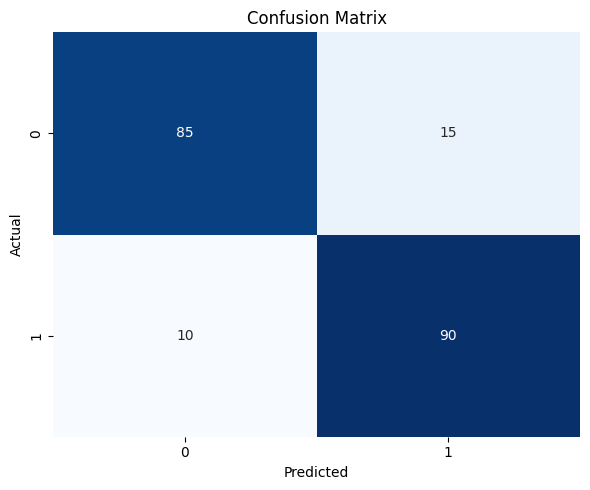

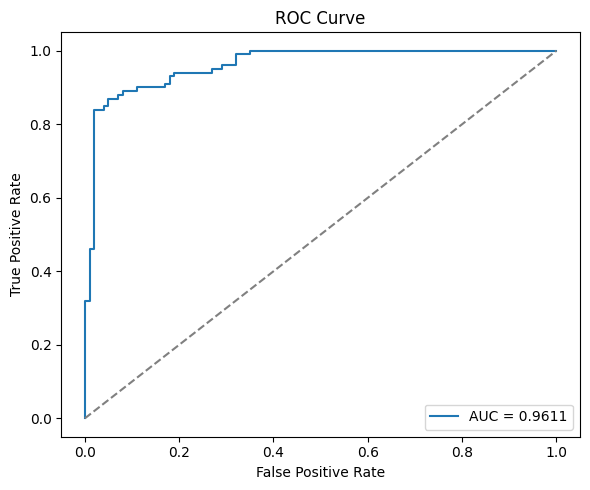

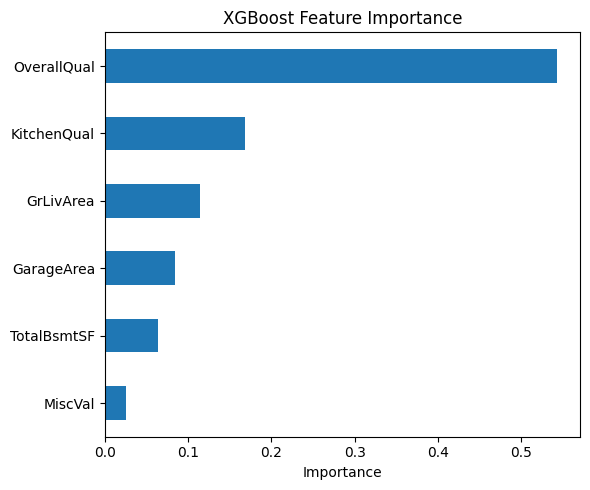

<Figure size 640x480 with 0 Axes>

OverallQual    0.543623
KitchenQual    0.168596
GrLivArea      0.114224
GarageArea     0.083863
TotalBsmtSF    0.064018
MiscVal        0.025677
dtype: float32

In [6]:
# 1) Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 2) ROC curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3) Feature importance
plt.figure(figsize=(6, 5))
feature_importance = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True)
feature_importance.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

feature_importance.sort_values(ascending=False)

### Brief summary
The XGBoost model predicts the binarized SalePrice strong performance in terms of Accuracy, F1, and AUC

Based on the feature-importance plot, variables linked with quality and area contribute most to the predictions, whereas additional field like MiscVal is not important

Confusion matrix confirms high accuracy, recall and precision

AUC close to 1 means the model almost perfectly ranks positive cases higher than negative ones. It shows high True Positive Rate with low False Positive Rate

In [7]:
#choosing samples closer to the decision boundary, because for confident prediction it was not possible to change prediction using only single feature
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
boundary_indices = np.argsort(np.abs(y_test_pred_proba - 0.5))[:3]
X_test_sample = X_test.iloc[boundary_indices]
X_test_sample

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal
Id,,,,,,
1384,0.444444,0.203843,0.406206,0.133552,0.666667,0.0
842,0.444444,0.227016,0.483780,0.106383,0.666667,0.0
702,0.666667,0.156368,0.372355,0.190507,0.333333,0.0


In [8]:
y_pred = xgb_model.predict(X_test_sample)
y_proba = xgb_model.predict_proba(X_test_sample)[:, 1]
y_proba

array([0.49483424, 0.507061  , 0.5101563 ], dtype=float32)

sample with id 100 has low overall quality, kitchen quality and smaller living area and doesn't have garage, hence it is classified as low cost

other samples have higher quality, and have garage, thats  why they are classified as 1


In [38]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

for i in range(len(X_test_sample)):
    print(f"\nSample {i}")
    print("Prediction:", y_pred[i])
    print("Probability:", y_proba[i])

    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))

    # sort by influence
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print("Most influencing features:")
    for f, v in contributions[:5]:
        print(f, v)



Sample 0
Prediction: 0
Probability: 0.49483424
Most influencing features:
OverallQual -1.3986568
KitchenQual 1.1228555
GrLivArea 0.80251247
TotalBsmtSF -0.76532567
GarageArea 0.2194567

Sample 1
Prediction: 1
Probability: 0.507061
Most influencing features:
TotalBsmtSF -1.7333064
GarageArea 1.2652645
OverallQual -1.1669356
KitchenQual 0.8979764
GrLivArea 0.76880324

Sample 2
Prediction: 1
Probability: 0.5101563
Most influencing features:
OverallQual 1.8685137
GrLivArea -1.2533717
KitchenQual -0.9118785
TotalBsmtSF 0.3569939
GarageArea -0.016982073


Sample 0 is slightly pushed toward class 0 due to strong negative impact from OverallQual and TotalBsmtSF, Sample 1 is pushed just over to class 1 mainly by strong positive influence from GarageArea outweighing negatives from TotalBsmtSF and OverallQual, and Sample 2 is classified as 1 because a strong positive contribution from OverallQual outweighs the negative effects of GrLivArea and KitchenQual

Sampling

In [43]:
import numpy as np

def empirical_sampling(model, x_row, eps_values):
    base = model.predict_proba([x_row])[0,1]
    
    results = []
    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    feature = contributions[0][0]
    print(feature)
    idx = X_test_sample.columns.get_loc(feature)

    for eps in eps_values:
        #all features are gain type
        if base > 0.5:
            sign = -1
        else:
            sign = 1

        x_new = x_row.copy().astype(float)
        x_new[idx] += eps * sign
        
        p = model.predict_proba([x_new])[0,1]
        pred = int(p > 0.5)
        
        results.append((eps, p, pred))
        
        if pred != int(base > 0.5):
            break
    return results

In [ ]:
for i in range(len(X_test_sample)):
    print(i)
    x = X_test_sample.iloc[i].values

    eps_values = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 100, 1000, 10000, 999999999999]

    results = empirical_sampling(xgb_model, x, eps_values)

    for r in results:
        print(r)

0
OverallQual
(0, np.float32(0.49483424), 0)
(0.001, np.float32(0.49483424), 0)
(0.01, np.float32(0.49483424), 0)
(0.05, np.float32(0.49483424), 0)
(0.1, np.float32(0.49483424), 0)
(0.2, np.float32(0.7558673), 1)
1
TotalBsmtSF
(0, np.float32(0.507061), 1)
(0.001, np.float32(0.507061), 1)
(0.01, np.float32(0.4892273), 0)
2
OverallQual
(0, np.float32(0.5101563), 1)
(0.001, np.float32(0.12389562), 0)


# Interpretation

user preferences: Higher overall quality - strongest driver
Larger living space & garage
Better kitchen quality,
user does not care about miscVal

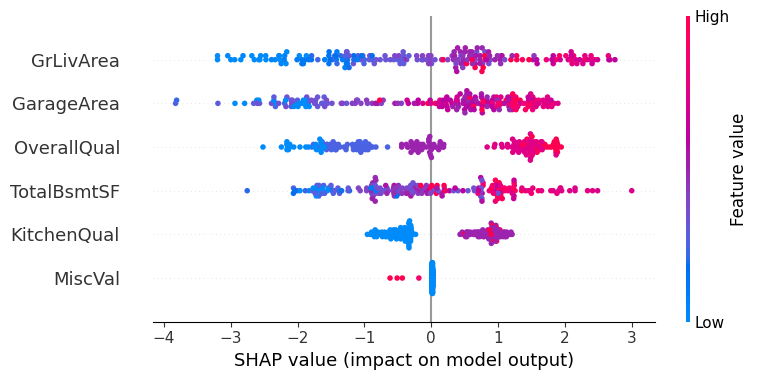

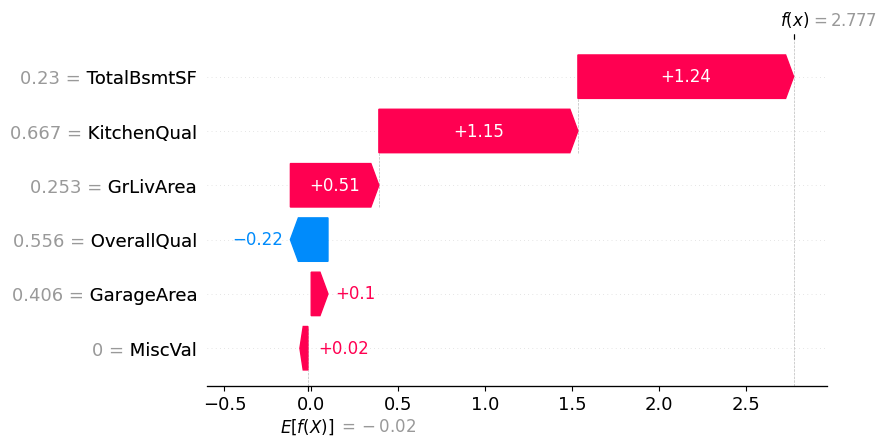

In [46]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

shap.waterfall_plot(shap_values[0])

Every feature is of a gain type and is monotonic

- GrLivArea: Strong positive effect; larger homes increase predictions.
- GarageArea: Positive impact; bigger garages generally raise predictions.
- OverallQual: Very important; higher quality sharply increases predictions.
- TotalBsmtSF: Strong positive effect; larger basements increase predictions.
- KitchenQual: High quality boosts predictions with clear threshold effects.
- MiscVal: Minimal impact; largely irrelevant to predictions.

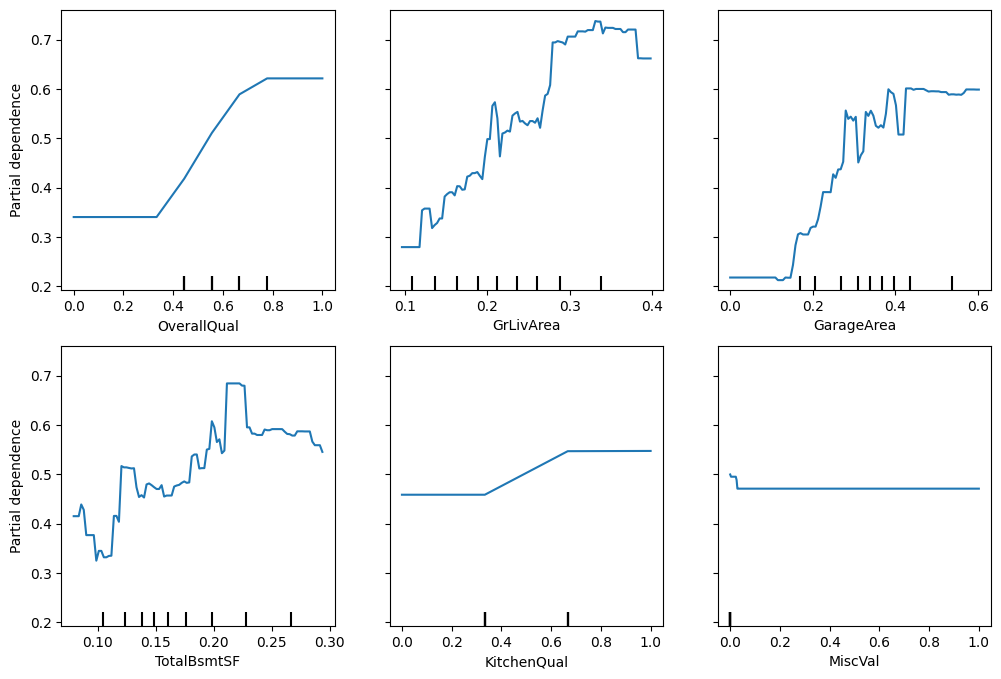

In [63]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [0, 1, 2, 3, 4, 5],
    ax=ax
)

plt.show()

partial dependency plot show how each feature affects the model's prediction on average, while holding other features constant.

- OverallQual: strongest positive effect (very important)
- GrLivArea, GarageArea: increase prediction, then level off
- KitchenQual: step-wise positive impact
- TotalBsmtSF: noisy, weaker/interaction-heavy effect
- MiscVal: no impact

dependencies: TotalBsmtSF is noisy - likely depends on OverallQual or GrLivArea

preference tresholds: 

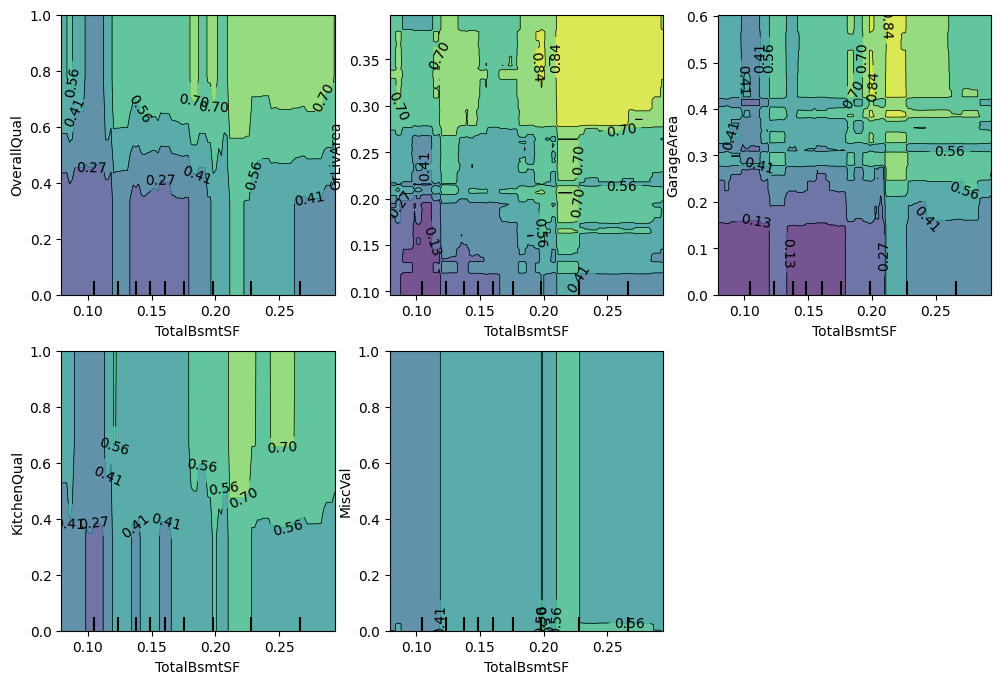

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [(3, i) for i in range(X_train.shape[1]) if i != 3],
    ax=ax,
)


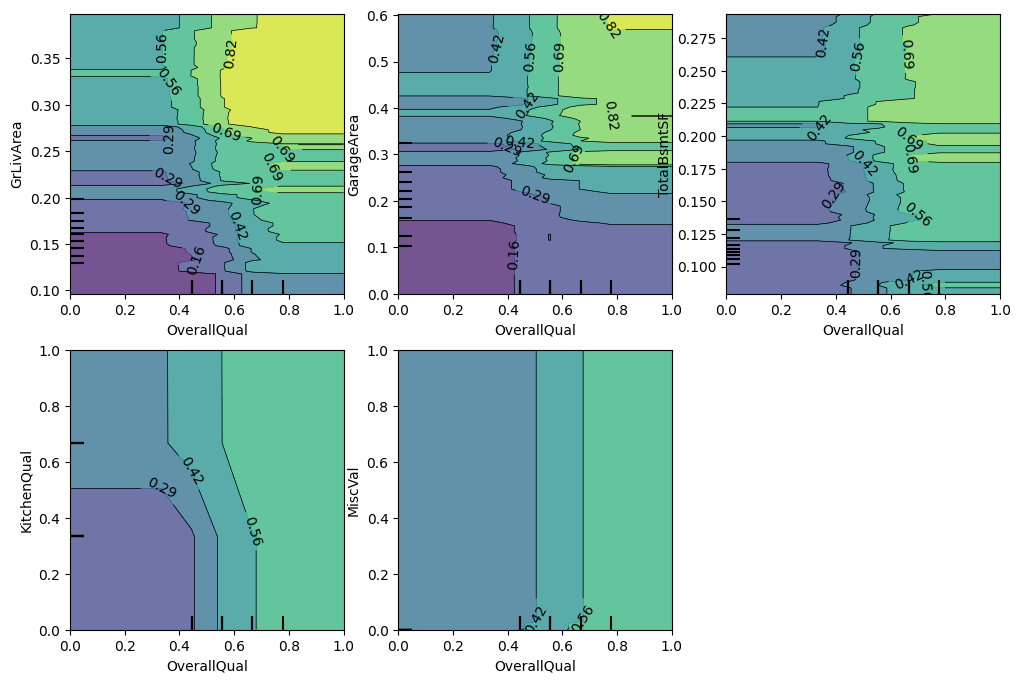

In [66]:
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [(0, i) for i in range(X_train.shape[1]) if i != 0],
    ax=ax,
)

# ANN-UTA


In [68]:
import sys
from pathlib import Path

import torch

_ROOT = Path.cwd()
_UTA_DIR = _ROOT / "UTA"
if str(_UTA_DIR) not in sys.path:
    sys.path.insert(0, str(_UTA_DIR))

from norm_layer import NormLayer
from uta import Uta

UTA_CHECKPOINT = _UTA_DIR / "uta.pt2"
NUM_HIDDEN = 30

feature_cols_uta = [c for c in df.columns if c != "SalePrice"]
num_criteria_uta = len(feature_cols_uta)

uta_model = Uta(num_criteria_uta, NUM_HIDDEN)
uta_model = NormLayer(uta_model, num_criteria_uta)

ckpt = torch.load(UTA_CHECKPOINT, map_location="cpu")
uta_model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [ ]:
with torch.no_grad():
    X_uta_test = torch.tensor(
        X_test[feature_cols_uta].values,
        dtype=torch.float32,
    ).reshape(-1, 1, num_criteria_uta)
    uta_margin = uta_wrapped(X_uta_test).detach().cpu().numpy().ravel()

y_pred_uta = (uta_margin > 0).astype(int)